# 02 - Hierarchical IDS Internal Test Evaluation

This notebook evaluates the locked Reviewer-3 hierarchical IDS on the canonical internal test split only: `processed_data/test_data.npz`.

The goal is to verify the real end-to-end hierarchy on the same rows used by the binary gate and the flat 34-class XGBoost baseline.


## 1. Setup and Paths

The notebook reads the internal-test artifacts generated by `evaluate_internal_test_comparison.py`. If the artifacts are missing, the script rebuilds them from the saved models and the same internal test split.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 90)
pd.set_option("display.max_rows", 90)
pd.set_option("display.width", 180)

ABLATION_DIR = Path.cwd()
if ABLATION_DIR.name != "Ablation Study":
    ABLATION_DIR = Path(r"D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\Ablation Study")
PROJECT_ROOT = ABLATION_DIR.parent
WORKSPACE_ROOT = Path(r"D:\Ml Project")

INTERNAL_DIR = PROJECT_ROOT / "results" / "ablation" / "internal_test"
FLAT_DIR = PROJECT_ROOT / "results" / "ablation" / "flat"
FIGURES_DIR = PROJECT_ROOT / "results" / "ablation" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INTERNAL_SCRIPT = ABLATION_DIR / "evaluate_internal_test_comparison.py"
TEST_NPZ_PATH = WORKSPACE_ROOT / "processed_data" / "test_data.npz"
SUMMARY_PATH = INTERNAL_DIR / "internal_test_flat_vs_hierarchical_summary.csv"
PER_CLASS_PATH = INTERNAL_DIR / "internal_test_per_class_comparison.csv"
BINARY_GATE_PATH = INTERNAL_DIR / "internal_test_binary_gate_summary.csv"
MANIFEST_PATH = INTERNAL_DIR / "internal_test_comparison_manifest.json"
HIER_PRED_PATH = INTERNAL_DIR / "hierarchical_internal_test_predictions.npz"
FLAT_PRED_PATH = FLAT_DIR / "flat_34class_test_predictions.npz"
REQUIRED_OUTPUTS = [SUMMARY_PATH, PER_CLASS_PATH, BINARY_GATE_PATH, MANIFEST_PATH, HIER_PRED_PATH]


def require_paths(paths, message="Missing required files"):
    missing = [str(Path(p)) for p in paths if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(message + ":\n" + "\n".join(missing))


def load_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def percent_frame(df, columns, decimals=2):
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = out[col].map(lambda v: f"{100 * float(v):.{decimals}f}%")
    return out


def show_table(title, df, percent_cols=None, decimals=2, max_rows=None):
    display(Markdown(f"**{title}**"))
    view = df.copy()
    if max_rows is not None:
        view = view.head(max_rows)
    if percent_cols:
        view = percent_frame(view, percent_cols, decimals=decimals)
    display(view)


def save_and_show(fig, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved figure: {path}")

FORCE_REBUILD_INTERNAL = False

missing_outputs = [p for p in REQUIRED_OUTPUTS if not p.exists()]
if FORCE_REBUILD_INTERNAL or missing_outputs:
    print("Running internal hierarchical comparison script...")
    subprocess.run([sys.executable, str(INTERNAL_SCRIPT)], cwd=str(ABLATION_DIR), check=True)
else:
    print("Internal-test outputs already exist. Set FORCE_REBUILD_INTERNAL=True to regenerate from scratch.")

require_paths([TEST_NPZ_PATH, FLAT_PRED_PATH, *REQUIRED_OUTPUTS], "Internal-test inputs are incomplete")
print("Ready.")


Internal-test outputs already exist. Set FORCE_REBUILD_INTERNAL=True to regenerate from scratch.
Ready.


## 2. Load Internal-Test Results

The hierarchical predictions were generated from `processed_data/test_data.npz` after reconstructing raw-equivalent features with `scaler.inverse_transform`. This is required because the hierarchical stages expect the feature scale used during their own training.


In [2]:
summary_df = pd.read_csv(SUMMARY_PATH)
per_class_df = pd.read_csv(PER_CLASS_PATH)
binary_gate_df = pd.read_csv(BINARY_GATE_PATH)
manifest = load_json(MANIFEST_PATH)

hier_npz = np.load(HIER_PRED_PATH, allow_pickle=True)
y_true = hier_npz["y_true_34class"].astype(np.int64)
y_pred = hier_npz["y_pred_34class"].astype(np.int64)
y_true_binary = hier_npz["y_true_binary"].astype(np.int64)
binary_pred = hier_npz["binary_pred"].astype(np.int64)
binary_prob = hier_npz["binary_prob"].astype(float)
confidence = hier_npz["confidence"].astype(float)
route_status = pd.Series(hier_npz["route_status"].astype(str), name="route_status")
family_pred = pd.Series(hier_npz["family_pred"].astype(str), name="family_pred")

hier_row = summary_df.loc[summary_df["model"].eq("Hierarchical IDS")].iloc[0]
flat_row = summary_df.loc[summary_df["model"].eq("Flat 34-class XGBoost")].iloc[0]

contract_df = pd.DataFrame([
    {"Item": "Evaluation split", "Value": str(TEST_NPZ_PATH)},
    {"Item": "Rows", "Value": f"{len(y_true):,}"},
    {"Item": "Raw reconstruction", "Value": manifest.get("raw_reconstruction", "")},
    {"Item": "Binary artifact mismatches", "Value": manifest.get("binary_prediction_mismatches_vs_saved_artifact")},
    {"Item": "Binary probability max absolute diff", "Value": f"{manifest.get('binary_prob_max_abs_diff_vs_saved_artifact'):.2e}"},
])
show_table("Internal-test contract", contract_df)


**Internal-test contract**

,Item,Value
0,Evaluation split,D:\Ml Project\processed_data\test_data.npz
1,Rows,"1,399,999"
2,Raw reconstruction,RobustScaler.inverse_transform(test_data.npz['...
3,Binary artifact mismatches,0
4,Binary probability max absolute diff,1.40e-06


**Interpretation.** The binary artifact mismatch count must be zero. That proves the notebook is using the same binary gate behavior as the saved Reviewer-3 binary-stage artifact.


## 3. Hierarchical Headline Metrics

This is the complete result after the binary gate, family classifier, and subtype classifiers are chained together.


In [3]:
hier_metrics = pd.DataFrame([
    {"Metric": "Accuracy", "Value": hier_row["accuracy"]},
    {"Metric": "Balanced accuracy / Macro recall", "Value": hier_row["balanced_accuracy"]},
    {"Metric": "Macro precision", "Value": hier_row["macro_precision"]},
    {"Metric": "Macro F1", "Value": hier_row["macro_f1"]},
    {"Metric": "Weighted F1", "Value": hier_row["weighted_f1"]},
    {"Metric": "MCC", "Value": hier_row["mcc"]},
])
show_table("Hierarchical IDS headline metrics", hier_metrics, percent_cols=["Value"])
display(Markdown(
    f"**Reading:** Hierarchical IDS reaches **{hier_row['accuracy']:.2%} accuracy**, "
    f"**{hier_row['macro_f1']:.2%} macro-F1**, and **{hier_row['weighted_f1']:.2%} weighted-F1**."
))


**Hierarchical IDS headline metrics**

,Metric,Value
0,Accuracy,98.52%
1,Balanced accuracy / Macro recall,93.23%
2,Macro precision,95.23%
3,Macro F1,94.13%
4,Weighted F1,98.50%
5,MCC,98.40%


**Reading:** Hierarchical IDS reaches **98.52% accuracy**, **94.13% macro-F1**, and **98.50% weighted-F1**.

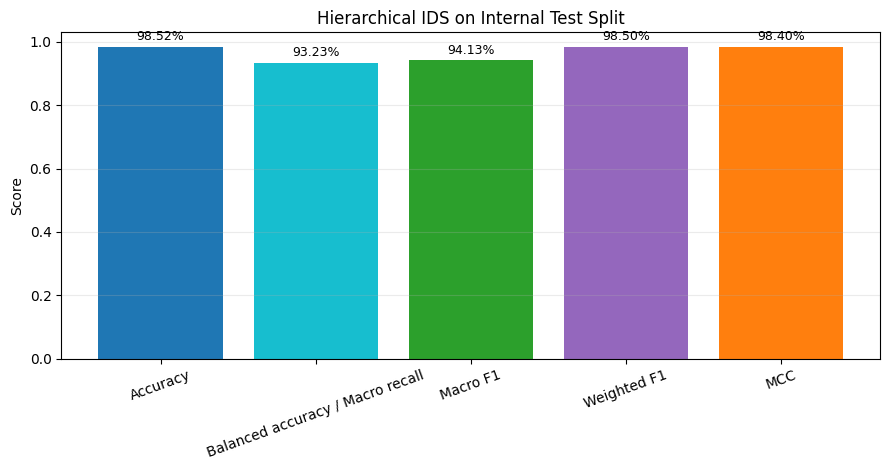

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_hierarchical_headline_metrics.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_metrics = hier_metrics[hier_metrics["Metric"].isin(["Accuracy", "Macro F1", "Weighted F1", "MCC", "Balanced accuracy / Macro recall"])]
ax.bar(plot_metrics["Metric"], plot_metrics["Value"], color=["#1f77b4", "#17becf", "#2ca02c", "#9467bd", "#ff7f0e"])
ax.set_ylim(0, 1.03)
ax.set_ylabel("Score")
ax.set_title("Hierarchical IDS on Internal Test Split")
ax.grid(axis="y", alpha=0.25)
for idx, value in enumerate(plot_metrics["Value"]):
    ax.text(idx, value + 0.012, f"{value:.2%}", ha="center", va="bottom", fontsize=9)
ax.tick_params(axis="x", rotation=20)
save_and_show(fig, FIGURES_DIR / "internal_test_hierarchical_headline_metrics.png")


**Interpretation.** Accuracy and weighted-F1 show strong overall behavior. Macro-F1 is the reviewer-facing metric because it gives rare subclasses equal weight.


## 4. Binary Gate Verification

The binary gate is the first routing decision. Attack rows predicted as benign stop early; benign rows predicted as attack enter the attack pipeline and become false alarms.


In [5]:
show_table("Binary gate summary", binary_gate_df, percent_cols=["accuracy", "macro_f1", "attack_precision", "attack_recall", "attack_miss_rate", "false_alarm_rate", "mcc"])
bg = binary_gate_df.iloc[0]
display(Markdown(
    f"**Reading:** At threshold **{bg['threshold']:.3f}**, attack recall is **{bg['attack_recall']:.2%}**, "
    f"attack miss rate is **{bg['attack_miss_rate']:.2%}**, and false alarm rate is **{bg['false_alarm_rate']:.2%}**. "
    f"Saved-artifact prediction mismatches: **{int(bg['saved_binary_prediction_mismatches'])}**."
))


**Binary gate summary**

,threshold,TN,FP,FN,TP,accuracy,macro_f1,attack_precision,attack_recall,attack_miss_rate,false_alarm_rate,mcc,saved_binary_prediction_mismatches,saved_binary_prob_max_abs_diff
0,0.454,213074,6565,9587,1170773,98.85%,97.83%,99.44%,99.19%,0.81%,2.99%,95.67%,0,0.000001


**Reading:** At threshold **0.454**, attack recall is **99.19%**, attack miss rate is **0.81%**, and false alarm rate is **2.99%**. Saved-artifact prediction mismatches: **0**.

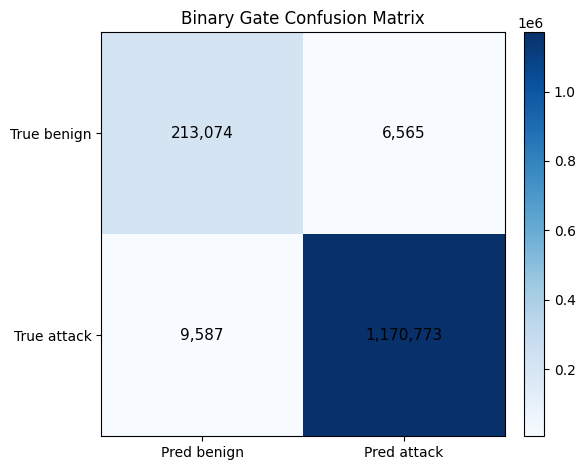

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_binary_gate_confusion_matrix.png


In [6]:
cm = np.array([[int(bg["TN"]), int(bg["FP"])], [int(bg["FN"]), int(bg["TP"])]])
fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred benign", "Pred attack"])
ax.set_yticks([0, 1], labels=["True benign", "True attack"])
ax.set_title("Binary Gate Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="black", fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
save_and_show(fig, FIGURES_DIR / "internal_test_binary_gate_confusion_matrix.png")


**Interpretation.** The binary gate is confirmed against the saved binary notebook artifact, so the end-to-end score is not caused by loading the wrong binary model or threshold.


## 5. Routing and Error Decomposition

This section shows how many rows follow each hierarchical route and where end-to-end mistakes originate.


In [7]:
route_df = route_status.value_counts().rename_axis("route_status").reset_index(name="rows")
route_df["share"] = route_df["rows"] / route_df["rows"].sum()
show_table("Hierarchical route distribution", route_df, percent_cols=["share"])

hier_correct = y_pred == y_true
binary_fn_mask = (y_true_binary == 1) & (binary_pred == 0)
binary_fp_mask = (y_true_binary == 0) & (binary_pred == 1)
subtype_error_mask = (~hier_correct) & ~(binary_fn_mask | binary_fp_mask)
error_df = pd.DataFrame([
    {"Error source": "Binary false negative", "Rows": int(binary_fn_mask.sum())},
    {"Error source": "Binary false positive", "Rows": int(binary_fp_mask.sum())},
    {"Error source": "Family/subtype error", "Rows": int(subtype_error_mask.sum())},
])
error_df["Share of hierarchical errors"] = error_df["Rows"] / max((~hier_correct).sum(), 1)
show_table("End-to-end error decomposition", error_df, percent_cols=["Share of hierarchical errors"])
display(Markdown(
    f"**Reading:** Total hierarchical errors: **{(~hier_correct).sum():,}**. "
    f"Binary gate errors account for **{(binary_fn_mask.sum() + binary_fp_mask.sum()) / max((~hier_correct).sum(), 1):.1%}** of them."
))


**Hierarchical route distribution**

,route_status,rows,share
0,subtype_predicted,1174905,83.92%
1,binary_benign,222661,15.90%
2,bruteforce_single_subtype,2433,0.17%


**End-to-end error decomposition**

,Error source,Rows,Share of hierarchical errors
0,Binary false negative,9587,46.22%
1,Binary false positive,6565,31.65%
2,Family/subtype error,4589,22.13%


**Reading:** Total hierarchical errors: **20,741**. Binary gate errors account for **77.9%** of them.

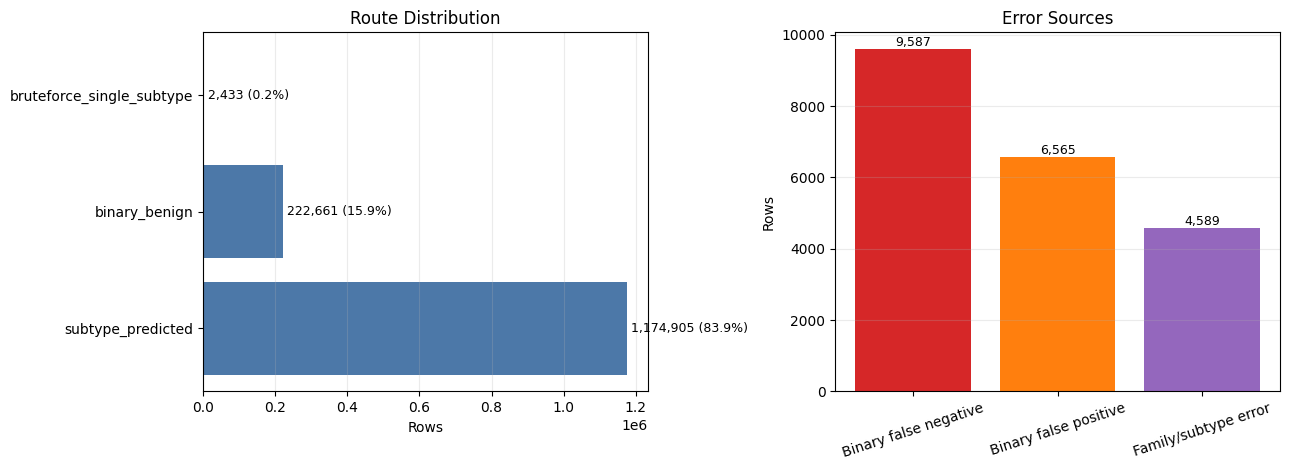

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_hierarchical_routes_and_errors.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].barh(route_df["route_status"], route_df["rows"], color="#4c78a8")
axes[0].set_title("Route Distribution")
axes[0].set_xlabel("Rows")
axes[0].grid(axis="x", alpha=0.25)
for y, row in enumerate(route_df.itertuples(index=False)):
    axes[0].text(row.rows, y, f" {row.rows:,} ({row.share:.1%})", va="center", fontsize=9)

axes[1].bar(error_df["Error source"], error_df["Rows"], color=["#d62728", "#ff7f0e", "#9467bd"])
axes[1].set_title("Error Sources")
axes[1].set_ylabel("Rows")
axes[1].grid(axis="y", alpha=0.25)
axes[1].tick_params(axis="x", rotation=18)
for idx, row in enumerate(error_df.itertuples(index=False)):
    axes[1].text(idx, row.Rows, f"{row.Rows:,}", ha="center", va="bottom", fontsize=9)
save_and_show(fig, FIGURES_DIR / "internal_test_hierarchical_routes_and_errors.png")


**Interpretation.** Every row has an explicit route. This confirms that the score is produced by the intended full hierarchy, not by a partial-stage shortcut.


## 6. Per-Class Hierarchical Performance

Macro-F1 depends on low-support subclasses, so the weakest and strongest classes are shown directly.


In [9]:
hier_class_table = per_class_df[["label", "hier_precision", "hier_recall", "hier_f1", "hier_support", "delta_f1"]].sort_values("hier_f1")
show_table("Lowest hierarchical F1 classes", hier_class_table.head(12), percent_cols=["hier_precision", "hier_recall", "hier_f1", "delta_f1"])
show_table("Highest hierarchical F1 classes", hier_class_table.tail(12).sort_values("hier_f1", ascending=False), percent_cols=["hier_precision", "hier_recall", "hier_f1", "delta_f1"])


**Lowest hierarchical F1 classes**

,label,hier_precision,hier_recall,hier_f1,hier_support,delta_f1
30,SqlInjection,60.33%,69.57%,64.62%,1091.0,-2.91%
28,Recon-PingSweep,83.96%,64.81%,73.15%,412.0,15.40%
27,Recon-OSScan,89.17%,77.11%,82.70%,19818.0,13.76%
31,Uploading_Attack,90.10%,76.55%,82.78%,226.0,20.60%
29,Recon-PortScan,84.92%,86.85%,85.87%,16262.0,13.53%
33,XSS,87.89%,84.56%,86.19%,790.0,29.56%
0,Backdoor_Malware,89.59%,84.82%,87.14%,639.0,25.89%
3,CommandInjection,90.09%,85.79%,87.89%,1070.0,24.76%
2,BrowserHijacking,92.60%,86.00%,89.18%,1150.0,21.57%
22,MITM-ArpSpoofing,96.82%,84.34%,90.15%,6704.0,10.20%


**Highest hierarchical F1 classes**

,label,hier_precision,hier_recall,hier_f1,hier_support,delta_f1
25,Mirai-udpplain,100.00%,100.00%,100.00%,19673.0,0.00%
9,DDoS-RSTFINFlood,100.00%,100.00%,100.00%,89411.0,0.00%
6,DDoS-ICMP_Flood,100.00%,100.00%,100.00%,158548.0,0.00%
8,DDoS-PSHACK_Flood,100.00%,99.99%,100.00%,90111.0,-0.00%
14,DDoS-UDP_Flood,99.99%,99.99%,99.99%,119774.0,0.02%
21,DoS-UDP_Flood,99.98%,99.99%,99.99%,72929.0,0.03%
4,DDoS-ACK_Fragmentation,99.97%,99.99%,99.98%,56937.0,0.00%
23,Mirai-greeth_flood,100.00%,99.97%,99.98%,21748.0,0.05%
24,Mirai-greip_flood,99.96%,99.99%,99.98%,16699.0,0.07%
18,DoS-HTTP_Flood,99.97%,99.97%,99.97%,14559.0,0.06%


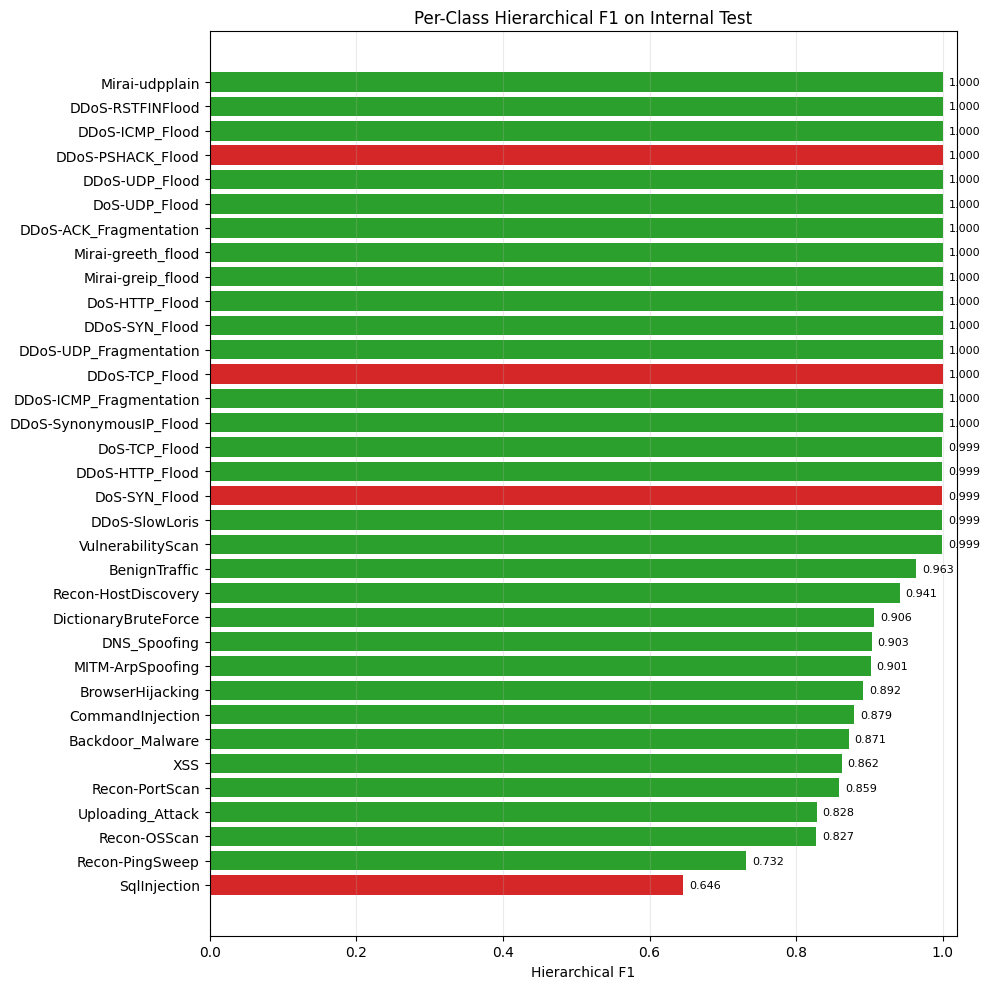

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_hierarchical_per_class_f1.png


In [10]:
plot_df = hier_class_table.sort_values("hier_f1", ascending=True)
fig, ax = plt.subplots(figsize=(10, 10))
colors = np.where(plot_df["delta_f1"] >= 0, "#2ca02c", "#d62728")
ax.barh(plot_df["label"], plot_df["hier_f1"], color=colors)
ax.set_xlim(0, 1.02)
ax.set_xlabel("Hierarchical F1")
ax.set_title("Per-Class Hierarchical F1 on Internal Test")
ax.grid(axis="x", alpha=0.25)
for y, value in enumerate(plot_df["hier_f1"]):
    ax.text(value + 0.008, y, f"{value:.3f}", va="center", fontsize=8)
save_and_show(fig, FIGURES_DIR / "internal_test_hierarchical_per_class_f1.png")


**Interpretation.** The hierarchy is strongest on high-support traffic families and improves most rare web/recon subclasses. SqlInjection remains the main rare-class exception.


## 7. Confidence Diagnostic

This diagnostic checks whether lower-confidence predictions are less reliable.


**Accuracy by hierarchical confidence bin**

,confidence_bin,rows,accuracy
0,"(-0.001, 0.5]",1776,28.94%
1,"(0.5, 0.7]",15683,57.56%
2,"(0.7, 0.85]",21702,77.16%
3,"(0.85, 0.95]",41437,89.29%
4,"(0.95, 1.0]",1319401,99.74%


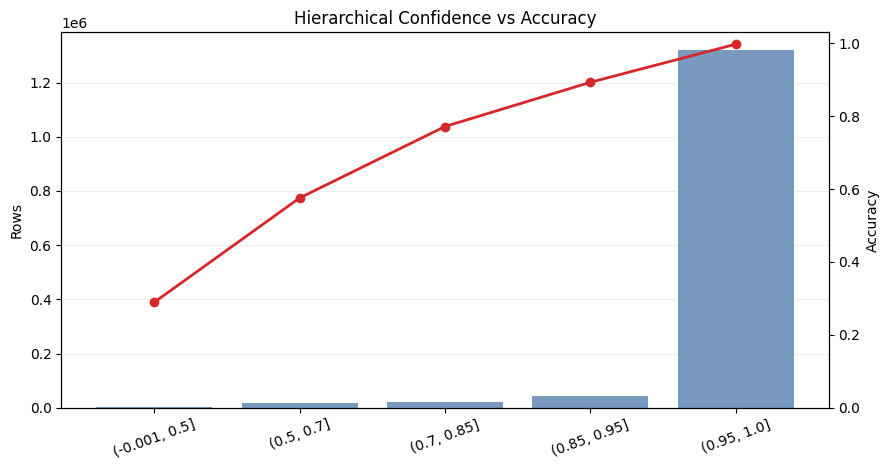

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_hierarchical_confidence_bins.png


In [11]:
conf_bins = pd.cut(confidence, bins=[0.0, 0.5, 0.7, 0.85, 0.95, 1.0000001], include_lowest=True)
confidence_df = pd.DataFrame({"confidence_bin": conf_bins, "correct": y_pred == y_true}).groupby("confidence_bin", observed=False).agg(
    rows=("correct", "size"), accuracy=("correct", "mean")
).reset_index()
confidence_df["confidence_bin"] = confidence_df["confidence_bin"].astype(str)
show_table("Accuracy by hierarchical confidence bin", confidence_df, percent_cols=["accuracy"])

fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.bar(confidence_df["confidence_bin"], confidence_df["rows"], color="#4c78a8", alpha=0.75)
ax1.set_ylabel("Rows")
ax1.tick_params(axis="x", rotation=20)
ax2 = ax1.twinx()
ax2.plot(confidence_df["confidence_bin"], confidence_df["accuracy"], color="#d62728", marker="o", linewidth=2)
ax2.set_ylim(0, 1.03)
ax2.set_ylabel("Accuracy")
ax1.set_title("Hierarchical Confidence vs Accuracy")
ax1.grid(axis="y", alpha=0.2)
save_and_show(fig, FIGURES_DIR / "internal_test_hierarchical_confidence_bins.png")


**Interpretation.** Confidence bins are a reviewer-friendly sanity check. They help separate model uncertainty from systematic routing errors.


## 8. Final Audit Checks

These assertions are intentionally strict. If any assertion fails, the notebook should not be used for the final paper table.


In [12]:
assert len(y_true) == int(hier_row["rows"]), "Prediction row count does not match summary row count."
assert int(binary_gate_df.loc[0, "saved_binary_prediction_mismatches"]) == 0, "Binary gate does not match saved binary artifact."
assert 0.0 <= float(hier_row["macro_f1"]) <= 1.0
assert int(route_df["rows"].sum()) == len(y_true), "Route coverage is incomplete."
print("Audit passed.")
print(f"Hierarchical macro-F1: {hier_row['macro_f1']:.6f}")
print(f"Hierarchical accuracy: {hier_row['accuracy']:.6f}")
print(f"Rows covered: {len(y_true):,}")


Audit passed.
Hierarchical macro-F1: 0.941272
Hierarchical accuracy: 0.985185
Rows covered: 1,399,999


**Conclusion.** This notebook is now an internal-test-only hierarchical evaluation. It verifies the binary gate, reports end-to-end performance, explains the main error sources, and shows inline figures suitable for review.
